# Materials Atlas — Atomic Bonding: Why Materials Hold Together

**The physical origin of structure and properties.** Learn why atoms settle into stable arrangements, why bonds prefer a distance, and why bonding shapes every later computational model.

- **Estimated duration:** 2–2.5 hours
- **Prerequisites:** `00-python-environment.ipynb`, `01-linear-algebra.ipynb`
- **Required packages:** NumPy, Matplotlib

> This is not a chemistry survey. It is an energy-based introduction to the interactions every atomistic simulation must represent.

## Learning objectives

By the end, you will be able to explain why atoms bond; read potential-energy and force curves; distinguish primary from secondary bonds; connect bonding to material properties and crystal structures; and recognize how bonding enters DFT, molecular dynamics, thermodynamics, and materials informatics.

## 1. Why do atoms bond?

Why does the universe not consist of isolated atoms? A set of atoms can often rearrange into a state with lower energy. Lower-energy arrangements are more stable: there is less energy available to release through a further change. Bonding is the interaction that makes particular atom-to-atom separations preferable.

Atoms do not “want” anything. They fluctuate and explore arrangements. At fixed conditions, the stable arrangements are associated with low energy. Begin with that physical picture; bond labels come later.

### Materials Atlas Connection

Thermodynamics (Module 03) expands this idea to free energy. DFT (Module 07) computes bonding from electrons. Molecular Dynamics (Module 08) moves atoms using forces from an interaction model.

## 2. The energy landscape

### Physical intuition

A marble at the bottom of a bowl returns after a small displacement: this is **stable equilibrium**. A marble balanced on a hill rolls away after a tiny displacement: this is **unstable equilibrium**. For atoms, the horizontal coordinate is separation distance. A stable bond similarly sits near a low point in energy.

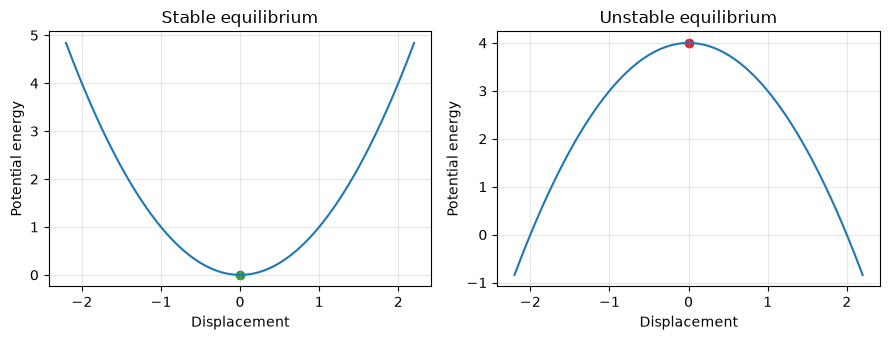

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2.2, 2.2, 400)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(x, x**2)
axes[0].scatter([0], [0], color="tab:green")
axes[0].set(title="Stable equilibrium", xlabel="Displacement", ylabel="Potential energy")
axes[1].plot(x, -x**2 + 4)
axes[1].scatter([0], [4], color="tab:red")
axes[1].set(title="Unstable equilibrium", xlabel="Displacement", ylabel="Potential energy")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### Reflection

Which marked point survives a small thermal disturbance? Why is an equilibrium more than simply a low numerical value?

### Materials Atlas Connection

Stable minima return as relaxed structures in DFT, stable phases in CALPHAD, and preferred defect configurations.

## 3. Attractive and repulsive interactions

### Physical intuition

At moderate separation, nuclei and electron density can produce an attractive tendency. At very short separation, electron-cloud overlap and quantum-mechanical restrictions create steep repulsion. Neither tendency alone creates a stable bond. Together they create an energy well: attraction pulls atoms together and repulsion prevents collapse.

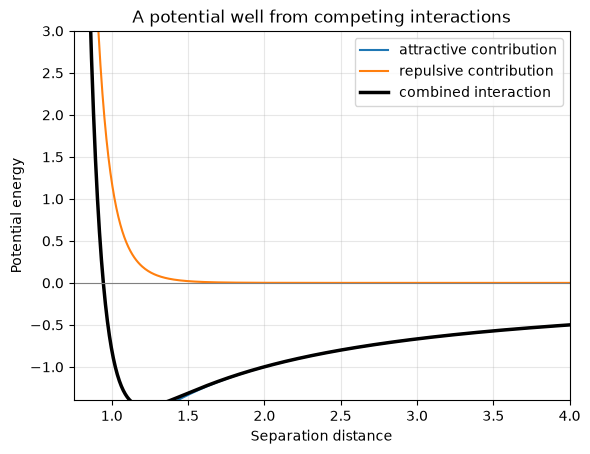

In [2]:
r = np.linspace(0.75, 4.0, 500)
attractive = -2.0 / r
repulsive = 1.2 / r**10
total = attractive + repulsive
fig, ax = plt.subplots()
ax.plot(r, attractive, label="attractive contribution")
ax.plot(r, repulsive, label="repulsive contribution")
ax.plot(r, total, color="black", linewidth=2.5, label="combined interaction")
ax.axhline(0, color="0.5", linewidth=0.8)
ax.set(xlim=(0.75, 4), ylim=(-1.4, 3), xlabel="Separation distance", ylabel="Potential energy", title="A potential well from competing interactions")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Experiment

Change the repulsive exponent or coefficient. Predict whether the well moves or becomes steeper, then test your prediction.

### Materials Atlas Connection

Classical interatomic potentials encode this competition explicitly; electronic-structure calculations obtain it from a quantum description of electrons and nuclei.

## 4. The potential-energy curve

### Physical intuition

The bottom of a bond-energy well is the equilibrium distance $r_0$. Its depth is a separation-energy scale. Its curvature near the bottom reveals stiffness: a narrow well resists small displacements more strongly than a broad one.

### Mathematics

Force is the negative energy slope: $F(r)=-dU/dr$. To the right of a minimum the force pulls inward; to the left it pushes outward.

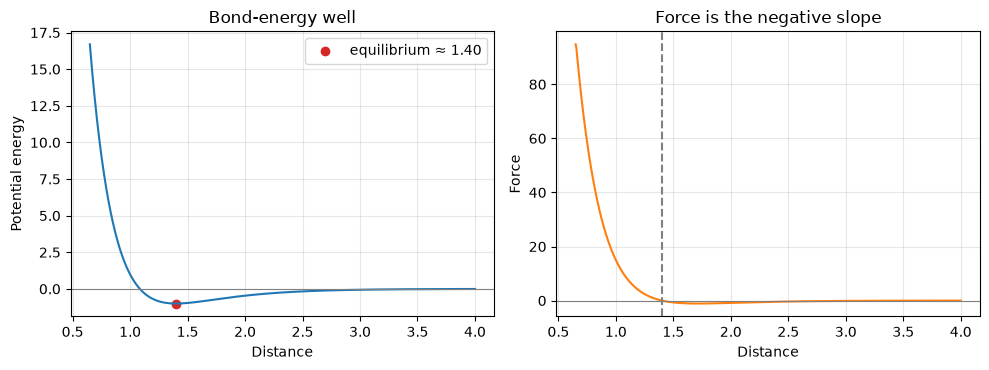

In [3]:
def morse_potential(distance, depth=1.0, stiffness=2.2, equilibrium=1.4):
    return depth * (1 - np.exp(-stiffness * (distance - equilibrium)))**2 - depth

r = np.linspace(0.65, 4.0, 500)
depth, stiffness, r0 = 1.0, 2.2, 1.4
energy = morse_potential(r, depth, stiffness, r0)
force = -np.gradient(energy, r)
minimum = np.argmin(energy)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(r, energy)
axes[0].scatter([r[minimum]], [energy[minimum]], color="tab:red", label=f"equilibrium ≈ {r[minimum]:.2f}")
axes[0].axhline(0, color="0.5", linewidth=0.8)
axes[0].set(xlabel="Distance", ylabel="Potential energy", title="Bond-energy well")
axes[0].legend()
axes[1].plot(r, force, color="tab:orange")
axes[1].axhline(0, color="0.5", linewidth=0.8)
axes[1].axvline(r0, color="0.5", linestyle="--")
axes[1].set(xlabel="Distance", ylabel="Force", title="Force is the negative slope")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### Experiment and reflection

Change `depth`, `stiffness`, or `r0`. Which parameter moves equilibrium? Which changes the response to a small displacement? At distances smaller than equilibrium, should the force push atoms closer or farther apart?

### Materials Atlas Connection

This curve is the conceptual core of energy minimization and force evaluation, the two activities that recur in DFT and molecular dynamics.

## 5. Why different elements behave differently

Atoms have nuclei surrounded by electrons. The outer, **valence electrons** are most available to participate in bonding. Different elements have different numbers, spatial distributions, and binding strengths for these electrons. That changes which arrangements lower energy.

The periodic table is a map of recurring electron behavior, not a vocabulary test. Loosely held electrons may be shared broadly; strongly attracting atoms can pull charge toward themselves; directional electron density can favor particular bond angles.

### Materials Atlas Connection

Electronic structure (Modules 06–07) supplies the detailed quantum explanation. Bonding is where electron behavior becomes visible as crystal structure and material properties.

## 6. Primary bonds

Primary bonds are comparatively strong interactions involving substantial electron rearrangement or sharing. The categories are useful limiting pictures; real materials can combine them.

- **Ionic:** electron density is transferred, leaving oppositely charged ions. Ceramics and oxides often show strong cohesion, high melting temperatures, and brittleness.
- **Covalent:** electron density is shared in specific directions. Diamond, silicon, and polymers illustrate how directionality can favor hard networks or semiconducting behavior.
- **Metallic:** valence electrons are shared across many atoms. Metals and alloys often combine electrical/thermal conductivity with ductility because atomic planes can rearrange while retaining cohesion.

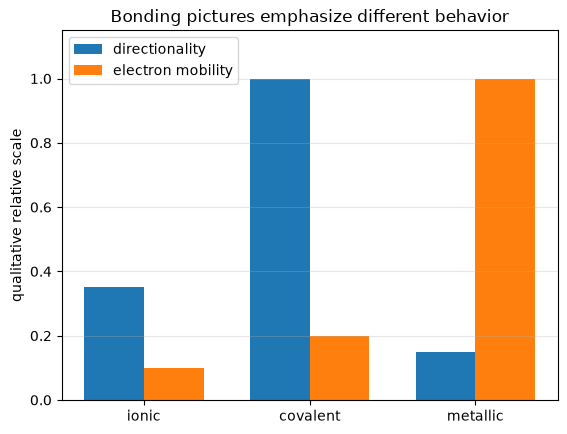

In [4]:
bond_types = ["ionic", "covalent", "metallic"]
directionality = np.array([0.35, 1.0, 0.15])
electron_mobility = np.array([0.10, 0.20, 1.0])
x = np.arange(3)
fig, ax = plt.subplots()
ax.bar(x - 0.18, directionality, 0.36, label="directionality")
ax.bar(x + 0.18, electron_mobility, 0.36, label="electron mobility")
ax.set(xticks=x, xticklabels=bond_types, ylim=(0, 1.15), ylabel="qualitative relative scale", title="Bonding pictures emphasize different behavior")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.show()

### Reflection

Which bond picture most naturally explains a conductive, readily shaped material? Which explains a hard, strongly directional network?

### Materials Atlas Connection

These pictures connect directly to crystal symmetry (Module 05), band structure (Modules 06–07), and mechanical behavior in atomistic simulation (Module 08).

## 7. Secondary bonds

**van der Waals** interactions arise from correlated or induced charge fluctuations. **Hydrogen bonding** is a particularly directional interaction involving hydrogen next to an electronegative atom. They are weaker than primary bonds, but “weak” is not “irrelevant”: many weak interactions shape polymers, biological materials, adsorption, interfaces, and layered 2D materials. Real materials also often exhibit **mixed bonding**—for example, partly ionic and partly covalent ceramics—so bond categories are explanatory models rather than mutually exclusive boxes.

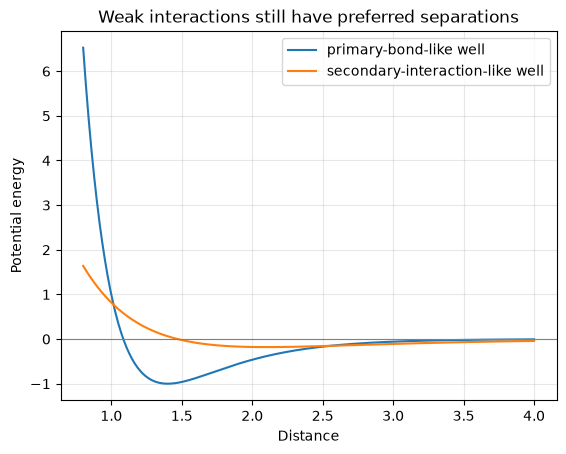

In [5]:
r = np.linspace(0.8, 4.0, 500)
strong = morse_potential(r, depth=1.0, stiffness=2.2, equilibrium=1.4)
weak = morse_potential(r, depth=0.18, stiffness=1.1, equilibrium=2.1)
fig, ax = plt.subplots()
ax.plot(r, strong, label="primary-bond-like well")
ax.plot(r, weak, label="secondary-interaction-like well")
ax.axhline(0, color="0.5", linewidth=0.8)
ax.set(xlabel="Distance", ylabel="Potential energy", title="Weak interactions still have preferred separations")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Experiment

Make the secondary well shallower or broader. How could many weak interactions still influence a material's shape or melting behavior?

### Materials Atlas Connection

Secondary interactions recur in polymers, interfaces, biomaterials, adsorption, and molecular simulations.

## 8. Bonding and material properties

Bonding is not the only cause of properties—defects, microstructure, temperature, and processing matter—but it sets the baseline. A deep well means more energy is needed to separate neighbors, so high bond energy often correlates with high melting temperature. The local slope of the force-distance curve near equilibrium determines stiffness: steeper restoring behavior corresponds to a larger elastic modulus. A deep, narrow and asymmetric energy trough also tends to correlate with lower thermal expansion, because thermal vibrations shift the average separation less. Electron mobility affects electrical and thermal conduction. Directionality and plane rearrangement influence hardness and ductility.

The recurring chain is: **electron behavior → bonding → atomic structure → properties → performance.**

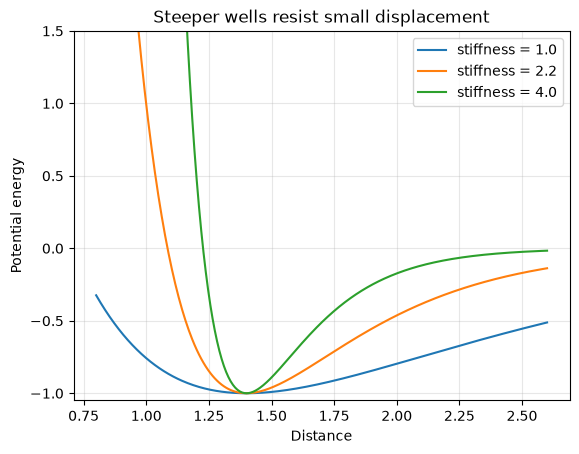

In [6]:
r = np.linspace(0.8, 2.6, 400)
fig, ax = plt.subplots()
for k in [1.0, 2.2, 4.0]:
    ax.plot(r, morse_potential(r, depth=1.0, stiffness=k, equilibrium=1.4), label=f"stiffness = {k}")
ax.set(ylim=(-1.05, 1.5), xlabel="Distance", ylabel="Potential energy", title="Steeper wells resist small displacement")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Reflection

Why is “stronger bond” not a complete prediction of ductility? What structural information would still matter?

### Materials Atlas Connection

This is the electronic-scale beginning of the Atlas processing–structure–properties–performance framework.

## 9. Bonding and crystal structures

If each atom has preferred neighbor distances and sometimes preferred directions, repeating an arrangement can lower the energy of many atoms at once. Ordered crystal structures are therefore a collective answer to local bonding preferences. Disorder, defects, competing interactions, and processing can produce glasses, alloys, and grain boundaries—but bonding remains the local rule set.

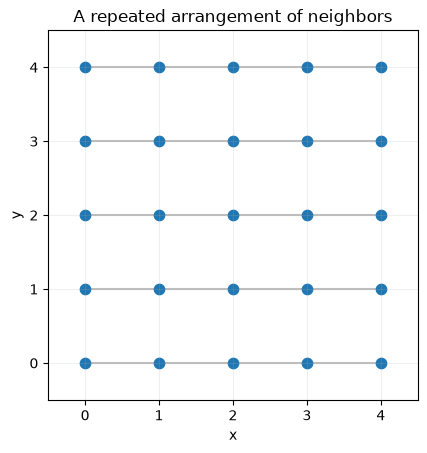

In [7]:
gx, gy = np.meshgrid(np.arange(5), np.arange(5))
positions = np.column_stack((gx.ravel(), gy.ravel()))
fig, ax = plt.subplots()
ax.scatter(positions[:, 0], positions[:, 1], s=55, color="tab:blue")
for point in positions:
    neighbor = point + [1, 0]
    if neighbor[0] < 5:
        ax.plot([point[0], neighbor[0]], [point[1], neighbor[1]], color="0.75", zorder=0)
ax.set(aspect="equal", xlim=(-0.5, 4.5), ylim=(-0.5, 4.5), xlabel="x", ylabel="y", title="A repeated arrangement of neighbors")
ax.grid(True, alpha=0.2)
plt.show()

### Materials Atlas Connection

Crystallography (Module 05) makes repeated arrangements precise with lattice vectors and symmetry. Electronic structure explains why one arrangement may be more stable than another.

## 10. Computational materials science connections

```mermaid
flowchart LR

B[Bonding]
E[Electronic Structure]
D[Density Functional Theory]
M[Molecular Dynamics]
C[CALPHAD]
P[Phase-Field]
I[Materials Informatics]
L[Learned Potentials]

B --> E
E --> D
B --> M
B --> C
C --> P
B --> I
I --> L
```

This diagram answers one question: **how does bonding connect Atlas methods?** Each method represents, approximates, or learns why atoms favor one arrangement over another.

DFT predicts bonding energy from electron behavior. Molecular dynamics evaluates an interatomic potential to obtain force. CALPHAD and phase-field work with thermodynamic free-energy landscapes. Materials informatics and machine learning use bond descriptors and learned potentials. Bonding is the common thread across these levels of description.

## 11. Interactive exploration

1. Return to the Morse-potential cell and increase `stiffness`; compare curvature near the minimum.
2. Change `r0`; observe that the preferred distance moves.
3. Change `depth`; explain why a deeper well requires more separation energy.
4. Compare primary and secondary wells. Identify a situation where many weak interactions matter.

For each: predict, change one parameter, run, then write one sentence of interpretation.

## 12. Mini project — Exploring Interatomic Potentials

The Lennard–Jones potential combines short-range repulsion and longer-range attraction:

$$U(r)=4\varepsilon\left[\left(\frac{\sigma}{r}\right)^{12}-\left(\frac{\sigma}{r}\right)^6\right].$$

$\varepsilon$ sets well depth and $\sigma$ sets distance scale. It is not universal, but it is an excellent laboratory for energy, force, and equilibrium intuition.

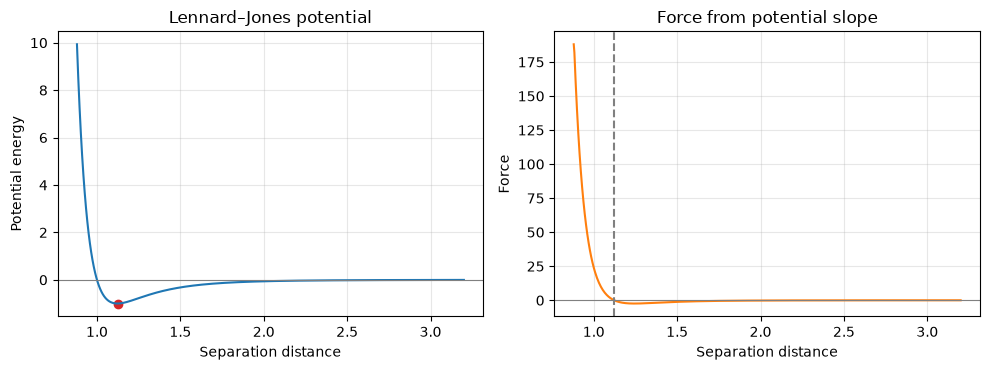

Equilibrium distance ≈ 1.124
Minimum energy ≈ -1.000


In [8]:
# Edit epsilon and sigma, predict the effect, then rerun.
epsilon = 1.0
sigma = 1.0
r = np.linspace(0.88 * sigma, 3.2 * sigma, 600)
lj_energy = 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)
lj_force = -np.gradient(lj_energy, r)
equilibrium = r[np.argmin(lj_energy)]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(r, lj_energy)
axes[0].scatter([equilibrium], [lj_energy.min()], color="tab:red")
axes[0].axhline(0, color="0.5", linewidth=0.8)
axes[0].set(xlabel="Separation distance", ylabel="Potential energy", title="Lennard–Jones potential")
axes[1].plot(r, lj_force, color="tab:orange")
axes[1].axhline(0, color="0.5", linewidth=0.8)
axes[1].axvline(equilibrium, color="0.5", linestyle="--")
axes[1].set(xlabel="Separation distance", ylabel="Force", title="Force from potential slope")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
print(f"Equilibrium distance ≈ {equilibrium:.3f}")
print(f"Minimum energy ≈ {lj_energy.min():.3f}")

### Project prompts

Double `epsilon`: what changes and what does not? Increase `sigma`: where does equilibrium move? Identify attractive and repulsive force regions. Add a Markdown cell explaining why this simplified model is still useful.

### Materials Atlas Connection

This previews molecular dynamics: positions determine energy, energy slope determines force, and force drives motion.

## 13. Reflection

1. Why do atoms bond?
2. Why is an energy minimum an equilibrium?
3. Why do stronger bonds often correlate with higher melting temperature?
4. Why does force depend on slope rather than energy value?
5. Why is bonding central to computational materials science?

If an answer is unclear, alter a plot parameter and observe the response.

## 14. Further exploration

This notebook's treatment of bonding forces, equilibrium separation, bonding energy, and bond-property correlations is aligned with Callister and Rethwisch, Chapter 2, *Atomic Structure and Interatomic Bonding*.


**Books:** William D. Callister Jr. and David G. Rethwisch, *Materials Science and Engineering: An Introduction*; Neil W. Ashcroft and N. David Mermin, *Solid State Physics*.

**Videos:** [MIT OpenCourseWare](https://ocw.mit.edu/) for materials-science and solid-state-chemistry lectures; 3Blue1Brown’s linear-algebra visualizations for the mathematical language used later.

**Software:** [ASE](../../resources/software/README.md#ase) for atomistic simulations; [pymatgen](../../resources/software/README.md#pymatgen) for structures and materials analysis.

**Atlas references:** [books](../../resources/books/README.md), [videos](../../resources/videos/README.md), and [foundational diagrams](../../references/diagrams/foundations.md).

## 15. Continue with

Continue to **[03-crystal-structures.ipynb](03-crystal-structures.ipynb)**. Bonding gives each atom preferred neighbors and distances; crystal structures show how those local preferences repeat into stable solid geometry.